In [1]:
import math
from typing import Optional

from botorch.acquisition.monte_carlo import MCAcquisitionFunction
from botorch.models.model import Model
from botorch.sampling.base import MCSampler
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils import t_batch_mode_transform
from torch import Tensor


class qScalarizedUpperConfidenceBound(MCAcquisitionFunction):
    def __init__(
        self,
        model: Model,
        beta: Tensor,
        weights: Tensor,
        sampler: Optional[MCSampler] = None,
    ) -> None:
        # we use the AcquisitionFunction constructor, since that of
        # MCAcquisitionFunction performs some validity checks that we don't want here
        super(MCAcquisitionFunction, self).__init__(model=model)
        if sampler is None:
            sampler = SobolQMCNormalSampler(sample_shape=torch.Size([512]))
        self.sampler = sampler
        self.register_buffer("beta", torch.as_tensor(beta))
        self.register_buffer("weights", torch.as_tensor(weights))

    @t_batch_mode_transform()
    def forward(self, X: Tensor) -> Tensor:
        """Evaluate scalarized qUCB on the candidate set `X`.

        Args:
            X: A `(b) x q x d`-dim Tensor of `(b)` t-batches with `q` `d`-dim
                design points each.

        Returns:
            Tensor: A `(b)`-dim Tensor of Upper Confidence Bound values at the
                given design points `X`.
        """
        posterior = self.model.posterior(X)
        samples = self.get_posterior_samples(posterior)  # n x b x q x o
        scalarized_samples = samples.matmul(self.weights)  # n x b x q
        mean = posterior.mean  # b x q x o
        scalarized_mean = mean.matmul(self.weights)  # b x q
        ucb_samples = (
            scalarized_mean
            + math.sqrt(self.beta * math.pi / 2)
            * (scalarized_samples - scalarized_mean).abs()
        )
        return ucb_samples.max(dim=-1)[0].mean(dim=0)


        

/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.utils import standardize
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.set_default_dtype(torch.double)

# generate synthetic data
X = torch.rand(20, 2)
Y = torch.stack([torch.sin(X[:, 0]), torch.cos(X[:, 1])], -1)

# construct and fit the multi-output model
gp = SingleTaskGP(train_X=X, train_Y=Y)
mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll)

# construct the acquisition function
qSUCB = qScalarizedUpperConfidenceBound(gp, beta=0.1, weights=torch.tensor([0.1, 0.5]))

In [3]:
# evaluate on single q-batch with q=3
qSUCB(torch.rand(3, 2))

tensor([0.5714], grad_fn=<MeanBackward1>)

In [4]:
# batch-evaluate on two q-batches with q=3
qSUCB(torch.rand(2, 3, 2))

tensor([0.5497, 0.5418], grad_fn=<MeanBackward1>)

In [5]:
from botorch.acquisition import AnalyticAcquisitionFunction


class ScalarizedUpperConfidenceBound(AnalyticAcquisitionFunction):
    def __init__(
        self,
        model: Model,
        beta: Tensor,
        weights: Tensor,
        maximize: bool = True,
    ) -> None:
        # we use the AcquisitionFunction constructor, since that of
        # AnalyticAcquisitionFunction performs some validity checks that we don't want here
        super(AnalyticAcquisitionFunction, self).__init__(model)
        self.maximize = maximize
        self.register_buffer("beta", torch.as_tensor(beta))
        self.register_buffer("weights", torch.as_tensor(weights))

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: Tensor) -> Tensor:
        """Evaluate the Upper Confidence Bound on the candidate set X using scalarization

        Args:
            X: A `(b) x d`-dim Tensor of `(b)` t-batches of `d`-dim design
                points each.

        Returns:
            A `(b)`-dim Tensor of Upper Confidence Bound values at the given
                design points `X`.
        """
        self.beta = self.beta.to(X)
        batch_shape = X.shape[:-2]
        posterior = self.model.posterior(X)
        means = posterior.mean.squeeze(dim=-2)  # b x o
        scalarized_mean = means.matmul(self.weights)  # b
        covs = posterior.mvn.covariance_matrix  # b x o x o
        weights = self.weights.view(
            1, -1, 1
        )  # 1 x o x 1 (assume single batch dimension)
        weights = weights.expand(batch_shape + weights.shape[1:])  # b x o x 1
        weights_transpose = weights.permute(0, 2, 1)  # b x 1 x o
        scalarized_variance = torch.bmm(
            weights_transpose, torch.bmm(covs, weights)
        ).view(
            batch_shape
        )  # b
        delta = (self.beta.expand_as(scalarized_mean) * scalarized_variance).sqrt()
        if self.maximize:
            return scalarized_mean + delta
        else:
            return scalarized_mean - delta

In [6]:
# construct the acquisition function
SUCB = ScalarizedUpperConfidenceBound(gp, beta=0.1, weights=torch.tensor([0.1, 0.5]))

In [7]:
# evaluate on single point
SUCB(torch.rand(1, 2))

tensor([0.4917], grad_fn=<AddBackward0>)

In [8]:
# batch-evaluate on 3 points
SUCB(torch.rand(3, 1, 2))

tensor([0.5185, 0.4297, 0.4606], grad_fn=<AddBackward0>)

In [9]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------------------------
# 1. Prepare Dataset
# ------------------------------------------------------------------------------

class AFMDataset(Dataset):
    """Custom Dataset to handle AFM pickle files with topo data and metadata."""
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
    
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        with open(fname, 'rb') as f:
            obj = pickle.load(f)

        topo = obj['topo'].data[0]  # use Height for simplicity
        topo = topo[None, :, :].astype(np.float32)  # [1, H, W]

        if self.transform:
            topo = self.transform(topo)

        # We'll use zeros for label and metadata here (since we are focusing on forward pass).
        label = 0
        metadata = np.ones(10, dtype=np.float32)

        return {
            'image': torch.tensor(topo),
            'label': label,
            'meta': torch.tensor(metadata)
        }

# ------------------------------------------------------------------------------
# 2. Define Model
# ------------------------------------------------------------------------------

class TipHealthNet(nn.Module):
    """CNN with an auxiliary regression output alongside main classifier."""
    def __init__(self, num_classes=2):
        super(TipHealthNet, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))  # output will always be 32x4x4
        )

        self.flatten = nn.Sequential(nn.Flatten())  # 32*4*4 = 512
        self.classifier = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, 2))
        self.regression = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, 1))
    
    def forward(self, x, metadata=None):
        """Forward pass. If metadata is provided, we could concat it; here we ignore it."""
        features = self.conv(x)  # [B, 32, 4, 4]
        flat = self.flatten(features)  # [B, 512]
        logits = self.classifier(flat)
        regression = self.regression(flat)
        return logits, regression

# ------------------------------------------------------------------------------
# 3. Main (example forward pass)

def main():
    """Example usage with directory of pickle files."""
    folder = 'scan_traces/MOBO'
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.pickle')]
    files = sorted(files)

    if not files:
        raise FileNotFoundError("No pickle files found in directory.")
        
    device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
    print(f"Using device: {device}")

    dataset = AFMDataset([files[0]])  # just first file for demonstration
    loader = DataLoader(dataset, batch_size=1)

    model = TipHealthNet()
    model = model.float()
    model = model.to(device)
    model.eval()

    batch = next(iter(loader))
    images = batch['image'].to(torch.float32).to(device)
    metadata = batch['meta'].to(torch.float32).to(device)

    with torch.no_grad():
        logits, regression = model(images, metadata)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        reg_val = regression.item()

    print(f"File: {os.path.basename(files[10])}")
    print(f"Class Probabilities → Healthy: {probs[0]:.3f}, Damaged: {probs[1]:.3f}")
    print(f"Regression Score (Tip wear proxy): {reg_val:.4f}")


if __name__ == "__main__":
    main()


Using device: mps
File: 250313_CaliSample_MOBO3.pickle
Class Probabilities → Healthy: 0.497, Damaged: 0.503
Regression Score (Tip wear proxy): 0.0330


Best parameters: x1 = 2.3462, x2 = 0.0000
Minimum value: -2.1660


<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

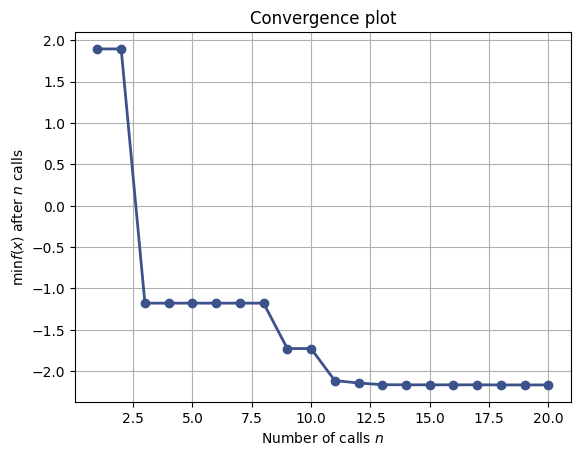

In [10]:
!pip install scikit-optimize
import numpy as np
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence

# Define the objective function to minimize
def objective_function(x):
    return (x[0] - 2) ** 2 + (x[1] - 3) + np.sin(x[0]) + np.sin(x[1])

# Define the search space
space = [Real(0.0, 5.0, name='x1'),  # Continuous space for x1
         Real(0.0, 5.0, name='x2')]  # Continuous space for x2

# Perform Bayesian Optimization
result = gp_minimize(objective_function,      # The function to minimize
                     space,                   # The search space
                     n_calls=20,              # The number of evaluations
                     random_state=42)         # Random state for reproducibility

# Print the best parameters and the corresponding minimum value
print("Best parameters: x1 = {:.4f}, x2 = {:.4f}".format(result.x[0], result.x[1]))
print("Minimum value: {:.4f}".format(result.fun))

# Plot convergence
plot_convergence(result)

/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


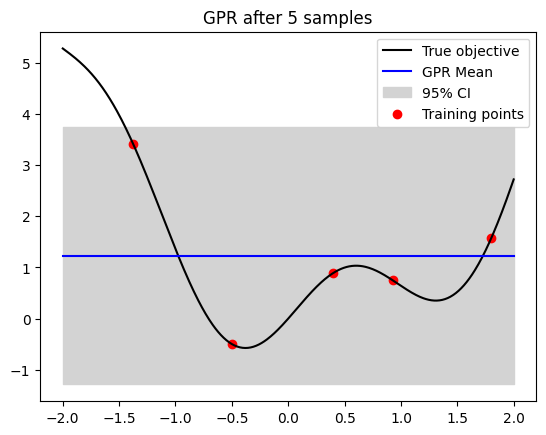

/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


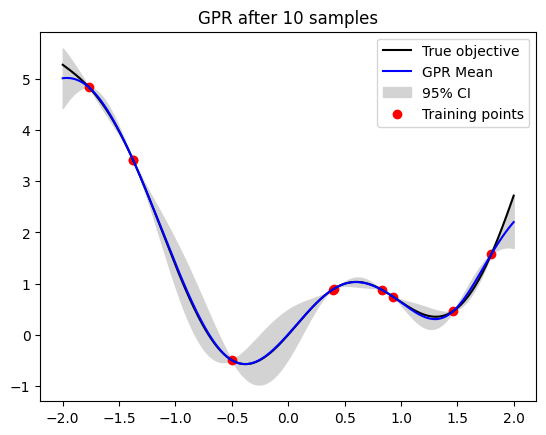

/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


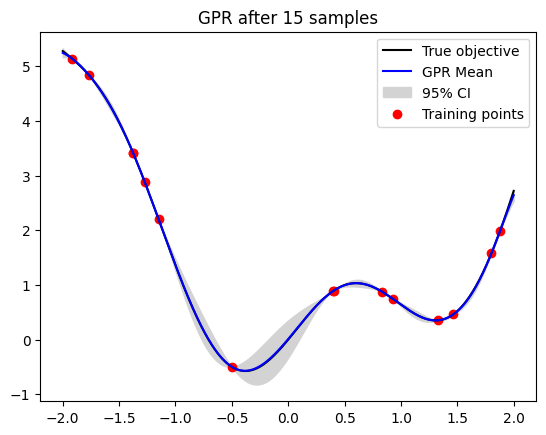

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# ------------------------------------------------------------------------------
# 1. Define objective and kernel
# ------------------------------------------------------------------------------

def objective(x):
    """Objective we want to minimize."""
    return np.sin(3 * x) + x ** 2 - 0.5 * x

kernel = Matern(length_scale=1.0, nu=2.5)

# ------------------------------------------------------------------------------
# 2. Initial samples
# ------------------------------------------------------------------------------

np.random.seed(42)
X = np.random.uniform(-2, 2, (15, 1))
y = objective(X).flatten()

# ------------------------------------------------------------------------------
# 3. Prepare GPR
# ------------------------------------------------------------------------------

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)

# ------------------------------------------------------------------------------
# 4. Plot convergence at 5, 10, and 15 samples
# ------------------------------------------------------------------------------

steps = [5, 10, 15]

x_vals = np.linspace(-2, 2, 500).reshape(-1, 1)
true_vals = objective(x_vals).flatten()

for n in steps:
    gp.fit(X[:n], y[:n])

    mu, sigma = gp.predict(x_vals, return_std=True)

    # Plotting
    plt.figure()
    plt.plot(x_vals, true_vals, label='True objective', color='black')
    plt.plot(x_vals, mu, label='GPR Mean', color='blue')
    plt.fill_between(x_vals.flatten(), mu - 1.96 * sigma, mu + 1.96 * sigma,
                     color='lightgrey', label='95% CI')
    plt.scatter(X[:n], y[:n], color='r', label='Training points')

    plt.title(f'GPR after {n} samples')
    plt.legend()
    plt.show()


In [17]:
import os
import pickle
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_sched
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet18
model = resnet18(pretrained=True)  # Deprecated in newer
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

# ------------------------------------------------------------------------------
# 1. Prepare Dataset
# ------------------------------------------------------------------------------

class AFMDataset(Dataset):
    """Custom Dataset to handle AFM pickle files with Height topo data and metadata."""
    def __init__(self, directory, transform=None):
        self.files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.pickle')]
        self.transform = transform
    
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        with open(fname, 'rb') as f:
            obj = pickle.load(f)

        topo = obj['topo'].data[0]  # use Height
        topo = topo[None, :, :].astype(np.float32)  # [1, H, W]

        if self.transform:
            topo = self.transform(topo)

        label = 0  # Here we use 0 or 1; in your labeled set, you'd put actual label
        regression = 0.5  # Here we use a fake regression; normally you'd have this from your data

        return topo, label, regression

transform = Compose([
    ToTensor(), 
    Resize((224, 224)), 
    Normalize(mean=[0.5], std=[0.5]) 
])

# ------------------------------------------------------------------------------
# 2. Define Model
# ------------------------------------------------------------------------------

def get_pretrained_model(num_classes):
    """Load a resnet18 and adjust first and last layer for single-channel and custom classes."""
    model = resnet18(weights='IMAGENET1K_V1')
    # Change first conv to single-channel
    model.conv1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
                                nn.BatchNorm2d(64),
                                nn.ReLU(),)

    in_features = model.fc.in_features
    model.classifier = nn.Sequential(nn.Linear(in_features, num_classes))

    # regression head
    model.regression = nn.Sequential(nn.Linear(in_features, 1))

    return model

# ------------------------------------------------------------------------------
# 3. Reward-weighted Loss
# ------------------------------------------------------------------------------

def reward_function(logits, labels):
    """Higher reward for hard samples (lower confidence) """
    probs = F.softmax(logits, dim=1)
    max_confidence, preds = probs.max(1)
    reward_vals = 1 - max_confidence
    return reward_vals.detach()

# ------------------------------------------------------------------------------
# 4. Training Loop
# ------------------------------------------------------------------------------

def train(model, dataloader, optimizer, device):
    """Train for a single epoch with reward-weighted classification + regression losses."""
    model.train()
    epoch_loss = 0
    for imgs, labels, regression_vals in dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        regression_vals = regression_vals.to(device).float()

        logits, regression = model(imgs)

        rewards = reward_function(logits, labels)

        ce_loss = F.cross_entropy(logits, labels, reduction='none')
        regression_loss = F.mse_loss(regression.view(-1), regression_vals, reduction='none')

        total_loss = (ce_loss * rewards).mean() + regression_loss.mean()

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()

    epoch_loss /= len(dataloader)
    return epoch_loss

def evaluate(model, dataloader, device):
    """Evaluation (without training) to compute average losses."""
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for imgs, labels, regression_vals in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            regression_vals = regression_vals.to(device).float()

            logits, regression = model(imgs)

            rewards = reward_function(logits, labels)

            ce_loss = F.cross_entropy(logits, labels, reduction='none')
            regression_loss = F.mse_loss(regression.view(-1), regression_vals, reduction='none')

            total_loss = (ce_loss * rewards).mean() + regression_loss.mean()
            epoch_loss += total_loss.item()

    epoch_loss /= len(dataloader)
    return epoch_loss

# ------------------------------------------------------------------------------
# 5. Main
# ------------------------------------------------------------------------------

def main():
    directory = "scan_traces/BO"

    dataset = AFMDataset(directory, transform=transform)

    # Split into training and validation
    train_length = int(0.8 * len(dataset))
    val_length = len(dataset) - train_length
    train_ds, val_ds = random_split(dataset, [train_length, val_length])

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=4)

    device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
    print(f"Using device: {device}")

    model = get_pretrained_model(num_classes=2).to(device)

    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    num_epochs = 10
    for epoch in range(1, num_epochs + 1):
        train_loss = train(model, train_loader, optimizer, device)
        val_loss = evaluate(model, val_loader, device)

        print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')

if __name__ == "__main__":
    main()


Using device: mps


TypeError: Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.